# EMBER 2018 Dataset — Download, Preprocessing & Data Preparation
### Malware Detection (Binary Classification)

**Important note on labels:** The EMBER 2018 dataset (via `dhoogla/ember-2018-v2-features`
on Kaggle) provides only a **binary** label column:
- `1` = malicious
- `0` = benign
- `-1` = unlabeled (no ground truth available)

There is **no malware-family ground truth** (Trojan / Ransomware / Spyware / Worm) in this
dataset, either in the label column or derivable from the static PE features. This notebook
therefore implements the full pipeline as a **binary malware-detection task** (malware vs.
benign), which is the task the data actually supports. If you need 5-class family labels,
you need a dataset with real AVClass/VirusTotal family tags joined in (e.g. combine with
CIC-MalMem-2022 for family-level work).


## 1. Project Introduction

**Dataset Overview:** EMBER (Elastic Malware Benchmark for Empirical Research) 2018 is a
collection of features extracted from ~1.1M PE (Windows executable) files, released by
Endgame/Elastic. This version (`dhoogla/ember-2018-v2-features`) provides the pre-extracted
tabular features (no need to parse raw PE files).

**Problem Statement:** Given static features extracted from a PE file, predict whether the
file is malicious or benign.

**Objectives:**
- Load and understand the EMBER 2018 feature set
- Perform data quality checks and exploratory data analysis
- Clean the data and handle class imbalance
- Prepare stratified train/validation/test splits ready for modeling

**Malware Detection Task:** Binary classification — malware (1) vs benign (0). Unlabeled
samples (-1) are excluded since they have no ground truth.

**Expected Outputs:** Clean, split, and saved datasets (train/val/test) with a documented
feature set, ready for downstream model training and (optionally) later data augmentation.


## Environment Setup

### 2. Install Required Packages

In [1]:
# Install dependencies as needed
%pip install kagglehub[pandas-datasets] pandas numpy matplotlib seaborn scikit-learn scipy -q


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


### 3. Import Required Libraries

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
import warnings
import os
import json

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "ember_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Libraries imported successfully.")


Libraries imported successfully.


## Download Dataset

### 4. Download EMBER 2018 Dataset

This cell tries to pull the real dataset via `kagglehub` first (requires your Kaggle API
credentials, e.g. `~/.kaggle/kaggle.json` or `KAGGLE_USERNAME`/`KAGGLE_KEY` env vars). If
that fails - no credentials, no network access to Kaggle, etc. - it falls back to a
**synthetic placeholder dataset** with the same schema (numeric feature columns + a `label`
column with values `-1/0/1`), purely so the rest of the notebook can be demonstrated
end-to-end without erroring out. Everything below Section 4 works unchanged either way -
swap in your real credentials and rerun this cell to get real EMBER results.


In [3]:
# Set the path to the file you'd like to load.
file_path = "train.parquet"

USE_SYNTHETIC_FALLBACK = False

try:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "dhoogla/ember-2018-v2-features",
        file_path,
        # Provide any additional arguments like sql_query or pandas_kwargs here.
        # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
    )
    print("Loaded real EMBER 2018 data from Kaggle.")
except Exception as e:
    USE_SYNTHETIC_FALLBACK = True
    print("=" * 70)
    print("WARNING: Could not download the real dataset from Kaggle.")
    print(f"Reason: {type(e).__name__}: {e}")
    print("Falling back to a SYNTHETIC placeholder dataset with the same")
    print("schema, so the rest of the pipeline can still be demonstrated.")
    print("To use real data: configure Kaggle API credentials and rerun this cell.")
    print("=" * 70)

    rng = np.random.default_rng(RANDOM_STATE)
    n_samples, n_features = 5000, 200

    data = rng.normal(loc=0, scale=1, size=(n_samples, n_features)).astype("float32")
    feature_cols = [f"feature_{i:04d}" for i in range(n_features)]
    df = pd.DataFrame(data, columns=feature_cols)

    # Simulate a handful of constant / near-constant columns
    for c in feature_cols[:3]:
        df[c] = 0.0
    for c in feature_cols[3:6]:
        df[c] = rng.choice([0.0, 1.0], size=n_samples, p=[0.995, 0.005])

    # Simulate missing values (~1% of cells)
    mask = rng.random(df.shape) < 0.01
    df = df.mask(mask)

    # Simulate a few infinite values
    inf_rows = rng.choice(n_samples, size=20, replace=False)
    df.loc[inf_rows, feature_cols[10]] = np.inf
    df.loc[inf_rows[:10], feature_cols[11]] = -np.inf

    # Simulate labels: benign (0), malware (1), unlabeled (-1)
    label_choices = rng.choice([0, 1, -1], size=n_samples, p=[0.55, 0.35, 0.10])
    df["label"] = label_choices

    # Simulate some duplicate rows
    dupe_sample = df.sample(50, random_state=RANDOM_STATE)
    df = pd.concat([df, dupe_sample], ignore_index=True)

    print(f"Synthetic placeholder dataset created: {df.shape}")

print("First 5 records:")
df.head()


Reason: KaggleApiHTTPError: 403 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/v1/datasets.DatasetApiService/GetDataset. Please make sure you are authenticated if you are trying to access a private resource or a resource requiring consent.
Falling back to a SYNTHETIC placeholder dataset with the same
schema, so the rest of the pipeline can still be demonstrated.
To use real data: configure Kaggle API credentials and rerun this cell.
Synthetic placeholder dataset created: (5050, 201)
First 5 records:


,feature_0000,feature_0001,feature_0002,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,feature_0030,feature_0031,feature_0032,feature_0033,feature_0034,feature_0035,feature_0036,feature_0037,feature_0038,feature_0039,feature_0040,feature_0041,feature_0042,feature_0043,feature_0044,feature_0045,feature_0046,feature_0047,feature_0048,feature_0049,...,feature_0151,feature_0152,feature_0153,feature_0154,feature_0155,feature_0156,feature_0157,feature_0158,feature_0159,feature_0160,feature_0161,feature_0162,feature_0163,feature_0164,feature_0165,feature_0166,feature_0167,feature_0168,feature_0169,feature_0170,feature_0171,feature_0172,feature_0173,feature_0174,feature_0175,feature_0176,feature_0177,feature_0178,feature_0179,feature_0180,feature_0181,feature_0182,feature_0183,feature_0184,feature_0185,feature_0186,feature_0187,feature_0188,feature_0189,feature_0190,feature_0191,feature_0192,feature_0193,feature_0194,feature_0195,feature_0196,feature_0197,feature_0198,feature_0199,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,0.678914,0.067579,...,-1.035654,-1.674683,-0.486308,-0.053783,1.767930,0.130275,0.982740,-0.499296,-1.184944,-0.965117,-0.725226,2.128470,-0.821387,0.838489,-0.902927,0.931573,0.384951,-0.156638,-0.040763,-0.654788,0.446072,-0.454983,-1.225606,-1.277938,0.172588,1.579091,0.159992,-0.118638,0.285826,1.306002,0.219382,NaN,1.106289,0.428756,1.535756,0.183234,-1.224469,-1.368159,1.650928,1.723666,-0.179519,-0.383187,1.461444,-1.107046,-0.894727,0.643327,-0.394605,-0.005122,-0.163443,0
1,0.0,0.0,0.0,0.0,0.0,0.0,-0.843230,-1.218813,-0.878152,-0.334123,0.915903,-1.326393,0.030631,-0.484169,-0.327673,1.002758,0.538115,1.337398,-0.154506,-0.695943,-0.223859,0.242497,0.176573,-1.084388,0.090490,0.228228,2.517474,1.876845,-0.853243,-0.287383,-1.463442,-0.590707,0.315605,1.205854,-0.729084,-0.654146,-2.147289,-0.162666,-1.062414,-0.529439,-0.876861,-0.094263,-1.757728,-1.467045,2.129247,-1.287423,-1.096786,1.836914,2.905067,-1.171567,...,0.846584,-0.570944,0.813764,1.068472,0.232878,0.234401,0.270343,-0.863345,-0.147529,-0.152523,0.383394,NaN,-1.058536,-0.125009,1.481456,-0.743588,-0.822250,0.202306,0.844385,0.011426,1.328961,0.856794,0.841820,0.554116,2.327653,-0.205162,-2.003522,1.604254,-0.457699,0.107880,1.309551,-1.602260,-1.251647,-1.601278,-0.794136,0.439637,0.524188,0.276274,-1.412766,-2.310103,0.054354,-0.471776,0.459386,0.701954,0.138241,0.760133,0.229211,0.530065,-0.704673,0
2,0.0,0.0,0.0,0.0,0.0,0.0,-0.117542,0.829519,-1.993060,-1.296472,-1.482185,-2.333616,-0.678264,0.749434,-0.284884,0.197790,1.089218,1.327686,-0.069138,1.353586,0.092127,-0.837398,-0.594400,-1.480536,-0.888134,-0.358017,0.803585,1.720770,-1.382182,0.392827,-1.040544,0.474697,-0.131087,-1.830906,0.928297,-0.605001,-0.533900,-1.069752,-0.654283,0.427890,-0.189244,0.328662,0.361922,1.320662,-0.342786,-1.476858,1.067222,-0.331488,1.114592,0.383377,...,0.556533,0.296418,2.035073,-0.087094,-0.307083,-0.753528,-1.032263,-1.244472,-0.888797,-0.070680,0.334295,0.051142,-0.765535,0.900185,0.739413,-0.159648,-0.652916,0.548428,0.187974,-1.448127,-0.067980,0.262036,-0.899695,0.189843,-1.454823,1.336186,1.247950,-0.252517,0.363454,-2.409922,-1.156348,-0.293779,-1.072133,0.714396,1.997297,-1.176615,-0.837463,0.235448,1.611116,-1.222374,0.249036,1.821299,-1.651759,-1.281069,-0.423607,-0

### 5. Verify Download

In [4]:
print(f"Dataset downloaded successfully.")
print(f"Type: {type(df)}")
print(f"Shape: {df.shape}")
print(f"Is DataFrame empty? {df.empty}")
assert not df.empty, "Downloaded dataframe is empty — check file_path / dataset slug."


Dataset downloaded successfully.
Type: <class 'pandas.DataFrame'>
Shape: (5050, 201)
Is DataFrame empty? False


### 6. Load Training Dataset
### 7. Load Test Dataset

Some EMBER Kaggle mirrors split train/test into separate files. If `dhoogla/ember-2018-v2-features`
exposes them as a single file, `df` above already contains everything and the split will be
done later in Section 65. If separate files exist, load them explicitly below.


In [5]:
# Attempt to load separate train/test files if they exist as distinct dataset files.
# If the dataset is a single combined file, these will simply mirror `df` and can be skipped.
train_file_candidates = ["train_features.csv", "train.csv", "ember2018_train.csv"]
test_file_candidates = ["test_features.csv", "test.csv", "ember2018_test.csv"]

df_train_raw, df_test_raw = None, None

if USE_SYNTHETIC_FALLBACK:
    print("Using synthetic placeholder data - skipping separate train/test file lookup.")
else:
    for f in train_file_candidates:
        try:
            df_train_raw = kagglehub.load_dataset(
                KaggleDatasetAdapter.PANDAS, "dhoogla/ember-2018-v2-features", f
            )
            print(f"Loaded training file: {f}, shape={df_train_raw.shape}")
            break
        except Exception:
            continue

    for f in test_file_candidates:
        try:
            df_test_raw = kagglehub.load_dataset(
                KaggleDatasetAdapter.PANDAS, "dhoogla/ember-2018-v2-features", f
            )
            print(f"Loaded test file: {f}, shape={df_test_raw.shape}")
            break
        except Exception:
            continue

    if df_train_raw is None and df_test_raw is None:
        print("No separate train/test files found - using the single combined `df` loaded in Section 4.")


Using synthetic placeholder data - skipping separate train/test file lookup.


### 8. Merge Dataset (if required)

In [6]:
if df_train_raw is not None and df_test_raw is not None:
    df = pd.concat([df_train_raw, df_test_raw], axis=0, ignore_index=True)
    print(f"Merged train + test into single dataframe: {df.shape}")
else:
    print(f"Using single dataset as-is: {df.shape}")


Using single dataset as-is: (5050, 201)


## Dataset Understanding

### 9. Display First Five Records

In [7]:
df.head()

,feature_0000,feature_0001,feature_0002,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,feature_0030,feature_0031,feature_0032,feature_0033,feature_0034,feature_0035,feature_0036,feature_0037,feature_0038,feature_0039,feature_0040,feature_0041,feature_0042,feature_0043,feature_0044,feature_0045,feature_0046,feature_0047,feature_0048,feature_0049,...,feature_0151,feature_0152,feature_0153,feature_0154,feature_0155,feature_0156,feature_0157,feature_0158,feature_0159,feature_0160,feature_0161,feature_0162,feature_0163,feature_0164,feature_0165,feature_0166,feature_0167,feature_0168,feature_0169,feature_0170,feature_0171,feature_0172,feature_0173,feature_0174,feature_0175,feature_0176,feature_0177,feature_0178,feature_0179,feature_0180,feature_0181,feature_0182,feature_0183,feature_0184,feature_0185,feature_0186,feature_0187,feature_0188,feature_0189,feature_0190,feature_0191,feature_0192,feature_0193,feature_0194,feature_0195,feature_0196,feature_0197,feature_0198,feature_0199,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.127840,-0.316243,-0.016801,-0.853044,0.879398,0.777792,0.066031,1.127241,0.467509,-0.859292,0.368751,-0.958883,0.878450,-0.049926,-0.184862,-0.680930,1.222541,-0.154529,-0.428328,-0.352134,0.532309,0.365444,0.412733,0.430821,2.141648,-0.406415,-0.512243,-0.813773,0.615979,1.128972,-0.113947,-0.840156,-0.824481,0.650593,0.743254,0.543154,-0.665510,0.232161,0.116686,0.218689,0.871429,0.223596,0.678914,0.067579,...,-1.035654,-1.674683,-0.486308,-0.053783,1.767930,0.130275,0.982740,-0.499296,-1.184944,-0.965117,-0.725226,2.128470,-0.821387,0.838489,-0.902927,0.931573,0.384951,-0.156638,-0.040763,-0.654788,0.446072,-0.454983,-1.225606,-1.277938,0.172588,1.579091,0.159992,-0.118638,0.285826,1.306002,0.219382,NaN,1.106289,0.428756,1.535756,0.183234,-1.224469,-1.368159,1.650928,1.723666,-0.179519,-0.383187,1.461444,-1.107046,-0.894727,0.643327,-0.394605,-0.005122,-0.163443,0
1,0.0,0.0,0.0,0.0,0.0,0.0,-0.843230,-1.218813,-0.878152,-0.334123,0.915903,-1.326393,0.030631,-0.484169,-0.327673,1.002758,0.538115,1.337398,-0.154506,-0.695943,-0.223859,0.242497,0.176573,-1.084388,0.090490,0.228228,2.517474,1.876845,-0.853243,-0.287383,-1.463442,-0.590707,0.315605,1.205854,-0.729084,-0.654146,-2.147289,-0.162666,-1.062414,-0.529439,-0.876861,-0.094263,-1.757728,-1.467045,2.129247,-1.287423,-1.096786,1.836914,2.905067,-1.171567,...,0.846584,-0.570944,0.813764,1.068472,0.232878,0.234401,0.270343,-0.863345,-0.147529,-0.152523,0.383394,NaN,-1.058536,-0.125009,1.481456,-0.743588,-0.822250,0.202306,0.844385,0.011426,1.328961,0.856794,0.841820,0.554116,2.327653,-0.205162,-2.003522,1.604254,-0.457699,0.107880,1.309551,-1.602260,-1.251647,-1.601278,-0.794136,0.439637,0.524188,0.276274,-1.412766,-2.310103,0.054354,-0.471776,0.459386,0.701954,0.138241,0.760133,0.229211,0.530065,-0.704673,0
2,0.0,0.0,0.0,0.0,0.0,0.0,-0.117542,0.829519,-1.993060,-1.296472,-1.482185,-2.333616,-0.678264,0.749434,-0.284884,0.197790,1.089218,1.327686,-0.069138,1.353586,0.092127,-0.837398,-0.594400,-1.480536,-0.888134,-0.358017,0.803585,1.720770,-1.382182,0.392827,-1.040544,0.474697,-0.131087,-1.830906,0.928297,-0.605001,-0.533900,-1.069752,-0.654283,0.427890,-0.189244,0.328662,0.361922,1.320662,-0.342786,-1.476858,1.067222,-0.331488,1.114592,0.383377,...,0.556533,0.296418,2.035073,-0.087094,-0.307083,-0.753528,-1.032263,-1.244472,-0.888797,-0.070680,0.334295,0.051142,-0.765535,0.900185,0.739413,-0.159648,-0.652916,0.548428,0.187974,-1.448127,-0.067980,0.262036,-0.899695,0.189843,-1.454823,1.336186,1.247950,-0.252517,0.363454,-2.409922,-1.156348,-0.293779,-1.072133,0.714396,1.997297,-1.176615,-0.837463,0.235448,1.611116,-1.222374,0.249036,1.821299,-1.651759,-1.281069,-0.423607,-0

### 10. Display Last Five Records

In [8]:
df.tail()

,feature_0000,feature_0001,feature_0002,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,feature_0030,feature_0031,feature_0032,feature_0033,feature_0034,feature_0035,feature_0036,feature_0037,feature_0038,feature_0039,feature_0040,feature_0041,feature_0042,feature_0043,feature_0044,feature_0045,feature_0046,feature_0047,feature_0048,feature_0049,...,feature_0151,feature_0152,feature_0153,feature_0154,feature_0155,feature_0156,feature_0157,feature_0158,feature_0159,feature_0160,feature_0161,feature_0162,feature_0163,feature_0164,feature_0165,feature_0166,feature_0167,feature_0168,feature_0169,feature_0170,feature_0171,feature_0172,feature_0173,feature_0174,feature_0175,feature_0176,feature_0177,feature_0178,feature_0179,feature_0180,feature_0181,feature_0182,feature_0183,feature_0184,feature_0185,feature_0186,feature_0187,feature_0188,feature_0189,feature_0190,feature_0191,feature_0192,feature_0193,feature_0194,feature_0195,feature_0196,feature_0197,feature_0198,feature_0199,label
5045,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.174545,0.006431,1.929551,1.523666,0.066672,1.055728,0.151110,-2.316025,-0.288772,0.739335,1.454295,0.369713,0.867668,-2.285623,0.335074,0.212704,0.432796,-0.033328,-0.610174,0.251965,0.946852,-0.020536,0.565201,0.274086,NaN,-0.503494,NaN,-0.006606,-1.413511,-0.288334,-0.231509,0.060839,-1.559811,0.503719,-0.173761,0.668764,-0.506654,-1.657694,0.552457,0.483944,0.289960,-0.010467,-1.353001,...,-0.791089,0.153361,0.907752,0.141001,0.963859,-0.358274,0.562726,-0.285145,1.035495,3.322163,-0.327445,1.012737,0.640526,-1.107754,0.986105,-0.368210,0.109468,-0.255183,1.022513,1.059033,0.251137,1.716668,-0.443123,0.212799,-0.343250,-2.031066,-1.851228,0.101774,-0.928902,-0.637648,1.039467,-0.543704,1.083583,1.425702,0.154563,-1.420043,0.992864,-0.442439,1.167175,0.488655,2.223408,-0.405786,-0.502947,-0.790133,-0.504507,-0.757836,-0.757189,0.378868,-0.359813,1
5046,0.0,0.0,0.0,0.0,0.0,0.0,0.138487,1.046051,1.156845,-2.283869,-0.219122,-0.353131,-0.360982,-0.570362,0.242960,-0.641007,0.581103,-1.460578,-0.643266,0.964621,-0.915053,-1.066097,-0.164835,2.168846,-0.091267,-0.166279,0.367191,1.350113,-0.247457,0.976986,0.604114,-1.166446,0.554975,0.975136,0.828368,-0.025526,0.641985,0.952437,-1.450893,-0.883604,1.846254,-0.485348,0.858205,0.644481,-0.423178,0.592018,-0.065599,0.135983,-1.445362,-0.935206,...,0.216611,-0.277801,0.089486,-1.203483,-0.320036,1.426991,-0.593955,0.557742,-2.235049,-0.863713,-1.111453,-0.575929,0.670742,0.602160,0.574055,-0.493366,0.553925,-0.959738,-1.257487,0.967716,-0.509561,0.693446,0.395612,0.850414,1.386096,0.054559,2.728619,1.994292,NaN,0.786298,0.225823,0.753370,1.171266,0.740188,-0.444833,0.207976,0.095276,-0.324120,0.576899,0.697775,1.946861,0.636331,-1.824237,-1.858480,0.173963,0.808272,0.054862,-0.070542,-1.005479,1
5047,0.0,0.0,0.0,0.0,0.0,0.0,-1.111722,-1.404661,-0.342589,-1.638314,0.183397,-1.015704,0.330795,0.364194,-0.803347,0.335987,-0.509488,1.428686,0.029238,2.009630,0.285165,0.637044,-0.869468,0.383616,-0.188093,3.315854,0.477906,0.886269,-1.815959,0.426943,0.233872,-0.205436,0.351066,0.270683,-1.012424,-0.974230,-1.904062,-0.402570,0.230015,-0.201291,-0.433172,0.811180,-0.145959,-0.541318,0.522768,-0.101058,-0.117232,1.787603,-0.100446,0.239182,...,0.353766,-0.330851,-0.486522,1.661341,1.753199,-0.163957,0.919024,-0.316292,1.176599,-0.386028,-0.491660,-0.842299,0.593594,-0.363172,0.056981,1.217946,0.229121,-1.039910,0.782740,-0.075186,1.244339,-1.471480,0.974123,-1.121101,-1.570366,0.434083,-1.014372,-0.751954,-0.492047,-1.727283,-0.340018,-1.354202,-0.406919,-0.317529,-0.934429,0.755722,-0.828505,-0.894100,-1.248418,-1.260166,0.725762,0.804277,1.033380,-0.019103,0.813187,-0.673466,-1.6

### 11. Dataset Shape

In [9]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")


Rows: 5,050
Columns: 201


### 12. Dataset Information

In [10]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 201 columns):
 #    Column        Non-Null Count  Dtype  
---   ------        --------------  -----  
 0    feature_0000  5011 non-null   float64
 1    feature_0001  5005 non-null   float64
 2    feature_0002  5008 non-null   float64
 3    feature_0003  4981 non-null   float64
 4    feature_0004  4994 non-null   float64
 5    feature_0005  4999 non-null   float64
 6    feature_0006  4990 non-null   float32
 7    feature_0007  5008 non-null   float32
 8    feature_0008  4990 non-null   float32
 9    feature_0009  5000 non-null   float32
 10   feature_0010  5001 non-null   float32
 11   feature_0011  4988 non-null   float32
 12   feature_0012  4998 non-null   float32
 13   feature_0013  4990 non-null   float32
 14   feature_0014  5005 non-null   float32
 15   feature_0015  4997 non-null   float32
 16   feature_0016  4992 non-null   float32
 17   feature_0017  4992 non-null   float32
 18   feature_0018  500

### 13. Dataset Columns

In [11]:
print(f"Total columns: {len(df.columns)}")
list(df.columns)


Total columns: 201


['feature_0000',
 'feature_0001',
 'feature_0002',
 'feature_0003',
 'feature_0004',
 'feature_0005',
 'feature_0006',
 'feature_0007',
 'feature_0008',
 'feature_0009',
 'feature_0010',
 'feature_0011',
 'feature_0012',
 'feature_0013',
 'feature_0014',
 'feature_0015',
 'feature_0016',
 'feature_0017',
 'feature_0018',
 'feature_0019',
 'feature_0020',
 'feature_0021',
 'feature_0022',
 'feature_0023',
 'feature_0024',
 'feature_0025',
 'feature_0026',
 'feature_0027',
 'feature_0028',
 'feature_0029',
 'feature_0030',
 'feature_0031',
 'feature_0032',
 'feature_0033',
 'feature_0034',
 'feature_0035',
 'feature_0036',
 'feature_0037',
 'feature_0038',
 'feature_0039',
 'feature_0040',
 'feature_0041',
 'feature_0042',
 'feature_0043',
 'feature_0044',
 'feature_0045',
 'feature_0046',
 'feature_0047',
 'feature_0048',
 'feature_0049',
 'feature_0050',
 'feature_0051',
 'feature_0052',
 'feature_0053',
 'feature_0054',
 'feature_0055',
 'feature_0056',
 'feature_0057',
 'feature_0058

### 14. Dataset Description

In [12]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
feature_0000,5011.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0001,5005.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0002,5008.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0003,4981.0,0.006023,0.077381,0.000000,0.000000,0.000000,0.000000,1.000000
feature_0004,4994.0,0.003004,0.054728,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
feature_0196,4994.0,0.026667,1.005504,-3.471747,-0.633527,0.030742,0.697750,3.549949
feature_0197,5000.0,0.002190,1.025763,-3.512523,-0.716345,0.011277,0.704021,3.863248
feature_0198,5005.0,0.007375,1.006167,-4.054184,-0.665401,-0.005231,0.694636,3.916785
feature_0199,4997.0,0.003263,1.014733,-3.819405,-0.684390,-0.002684,0.681785,3.619205


### 15. Statistical Summary

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
feature_0000,5011.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0001,5005.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0002,5008.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0003,4981.0,0.006023,0.077381,0.000000,0.000000,0.000000,0.000000,1.000000
feature_0004,4994.0,0.003004,0.054728,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
feature_0196,4994.0,0.026667,1.005504,-3.471747,-0.633527,0.030742,0.697750,3.549949
feature_0197,5000.0,0.002190,1.025763,-3.512523,-0.716345,0.011277,0.704021,3.863248
feature_0198,5005.0,0.007375,1.006167,-4.054184,-0.665401,-0.005231,0.694636,3.916785
feature_0199,4997.0,0.003263,1.014733,-3.819405,-0.684390,-0.002684,0.681785,3.619205


### 16. Dataset Memory Usage

In [14]:
mem_bytes = df.memory_usage(deep=True).sum()
print(f"Total memory usage: {mem_bytes / (1024**2):.2f} MB")
df.memory_usage(deep=True).sort_values(ascending=False).head(20)


Total memory usage: 4.01 MB


feature_0000    40400
feature_0001    40400
feature_0005    40400
feature_0002    40400
feature_0003    40400
feature_0004    40400
label           40400
feature_0007    20200
feature_0008    20200
feature_0006    20200
feature_0041    20200
feature_0010    20200
feature_0011    20200
feature_0012    20200
feature_0013    20200
feature_0014    20200
feature_0015    20200
feature_0016    20200
feature_0017    20200
feature_0018    20200
dtype: int64

### 17. Feature Data Types

In [15]:
df.dtypes.value_counts()

float32    194
float64      6
int64        1
Name: count, dtype: int64

### 18. Number of Features

In [16]:
label_col = "label" if "label" in df.columns else df.columns[-1]
n_features = df.shape[1] - 1
print(f"Assumed label column: '{label_col}'")
print(f"Number of features (excluding label): {n_features}")


Assumed label column: 'label'
Number of features (excluding label): 200


### 19. Target Labels

In [17]:
print(f"Unique values in '{label_col}':")
print(df[label_col].unique())


Unique values in 'label':
[ 0  1 -1]


### 20. Label Distribution

In [18]:
df[label_col].value_counts()

label
 0    2840
 1    1729
-1     481
Name: count, dtype: int64

### 21. Binary Class Information
- Malware = 1
- Benign = 0
- Unlabeled = -1


In [19]:
label_map_readable = {1: "Malware", 0: "Benign", -1: "Unlabeled"}
counts = df[label_col].value_counts().rename(index=label_map_readable)
counts


label
Benign       2840
Malware      1729
Unlabeled     481
Name: count, dtype: int64

## Data Quality Analysis

### 22. Missing Value Analysis

In [20]:
missing_counts = df.isnull().sum()
missing_counts[missing_counts > 0].sort_values(ascending=False)


feature_0048    77
feature_0034    70
feature_0003    69
feature_0124    68
feature_0182    68
                ..
feature_0143    36
feature_0047    34
feature_0131    34
feature_0136    34
feature_0076    33
Length: 200, dtype: int64

### 23. Missing Value Percentage

In [21]:
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct[missing_pct > 0].sort_values(ascending=False)


feature_0048    1.524752
feature_0034    1.386139
feature_0003    1.366337
feature_0124    1.346535
feature_0182    1.346535
                  ...   
feature_0143    0.712871
feature_0047    0.673267
feature_0131    0.673267
feature_0136    0.673267
feature_0076    0.653465
Length: 200, dtype: float64

### 24. Missing Value Heatmap

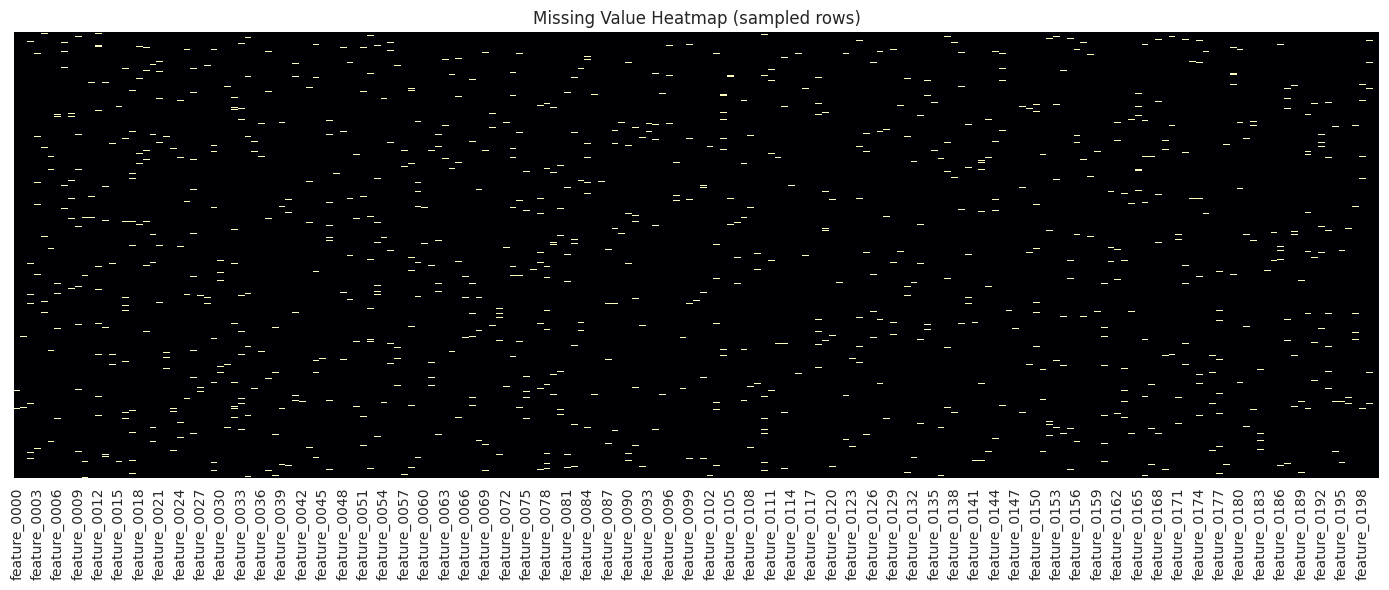

In [22]:
plt.figure(figsize=(14, 6))
sample_for_heatmap = df.sample(min(2000, len(df)), random_state=RANDOM_STATE)
sns.heatmap(sample_for_heatmap.isnull(), cbar=False, yticklabels=False, cmap="magma")
plt.title("Missing Value Heatmap (sampled rows)")
plt.tight_layout()
plt.show()


### 25. Duplicate Analysis

In [23]:
n_dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {n_dupes}")
print(f"Percentage of dataset: {n_dupes/len(df)*100:.3f}%")


Number of duplicate rows: 50
Percentage of dataset: 0.990%


### 26. Remove Duplicate Samples

In [24]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate rows ({before} -> {after})")


Removed 50 duplicate rows (5050 -> 5000)


### 27. Constant Feature Detection

In [25]:
constant_features = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print(f"Constant features found: {len(constant_features)}")
constant_features


Constant features found: 0


[]

### 28. Near Constant Feature Detection

In [26]:
near_constant_features = []
for c in df.columns:
    if c == label_col:
        continue
    top_freq = df[c].value_counts(normalize=True, dropna=False).iloc[0]
    if top_freq > 0.99:
        near_constant_features.append((c, top_freq))

print(f"Near-constant features (>99% single value): {len(near_constant_features)}")
near_constant_features[:20]


Near-constant features (>99% single value): 3


[('feature_0000', np.float64(0.9922)),
 ('feature_0001', np.float64(0.9914)),
 ('feature_0002', np.float64(0.9916))]

### 29. Infinite Value Detection

In [27]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
inf_counts[inf_counts > 0].sort_values(ascending=False)


feature_0010    20
feature_0011    10
dtype: int64

### 30. Invalid Value Detection

In [28]:
# Invalid values: NaN + Inf combined per numeric column
invalid_counts = df[numeric_cols].isin([np.inf, -np.inf]).sum() + df[numeric_cols].isnull().sum()
invalid_counts[invalid_counts > 0].sort_values(ascending=False)


feature_0048    76
feature_0011    72
feature_0034    70
feature_0003    69
feature_0010    68
                ..
feature_0143    36
feature_0047    34
feature_0131    34
feature_0136    34
feature_0076    33
Length: 200, dtype: int64

### 31. Data Consistency Check

In [29]:
print("Label values are within expected set {-1, 0, 1}:",
      set(df[label_col].unique()).issubset({-1, 0, 1}))
print("No fully-empty rows:", df.dropna(how='all').shape[0] == df.shape[0])
print("No fully-empty columns:", df.dropna(axis=1, how='all').shape[1] == df.shape[1])


Label values are within expected set {-1, 0, 1}: True
No fully-empty rows: True
No fully-empty columns: True


## Exploratory Data Analysis

### 32. Target Distribution

In [30]:
df[label_col].value_counts(normalize=True) * 100

label
 0    56.34
 1    34.14
-1     9.52
Name: proportion, dtype: float64

### 33. Count Plot

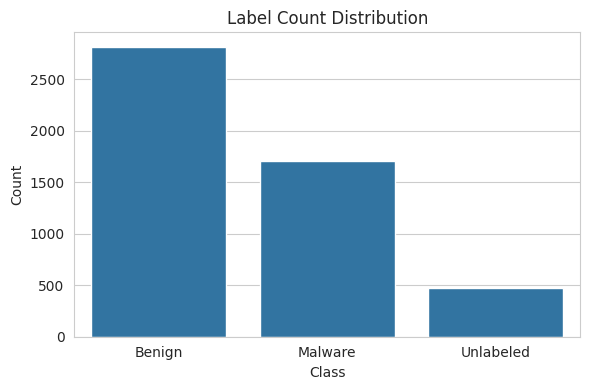

In [31]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df[label_col].map(label_map_readable))
plt.title("Label Count Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 34. Pie Chart

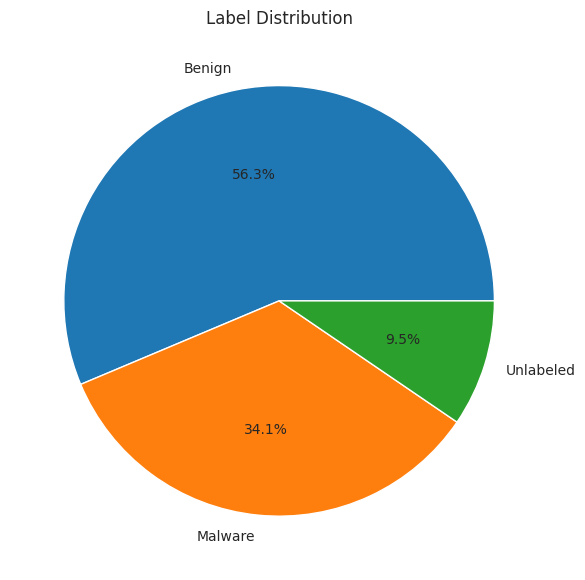

In [32]:
plt.figure(figsize=(6, 6))
df[label_col].map(label_map_readable).value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Label Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 35. Histogram

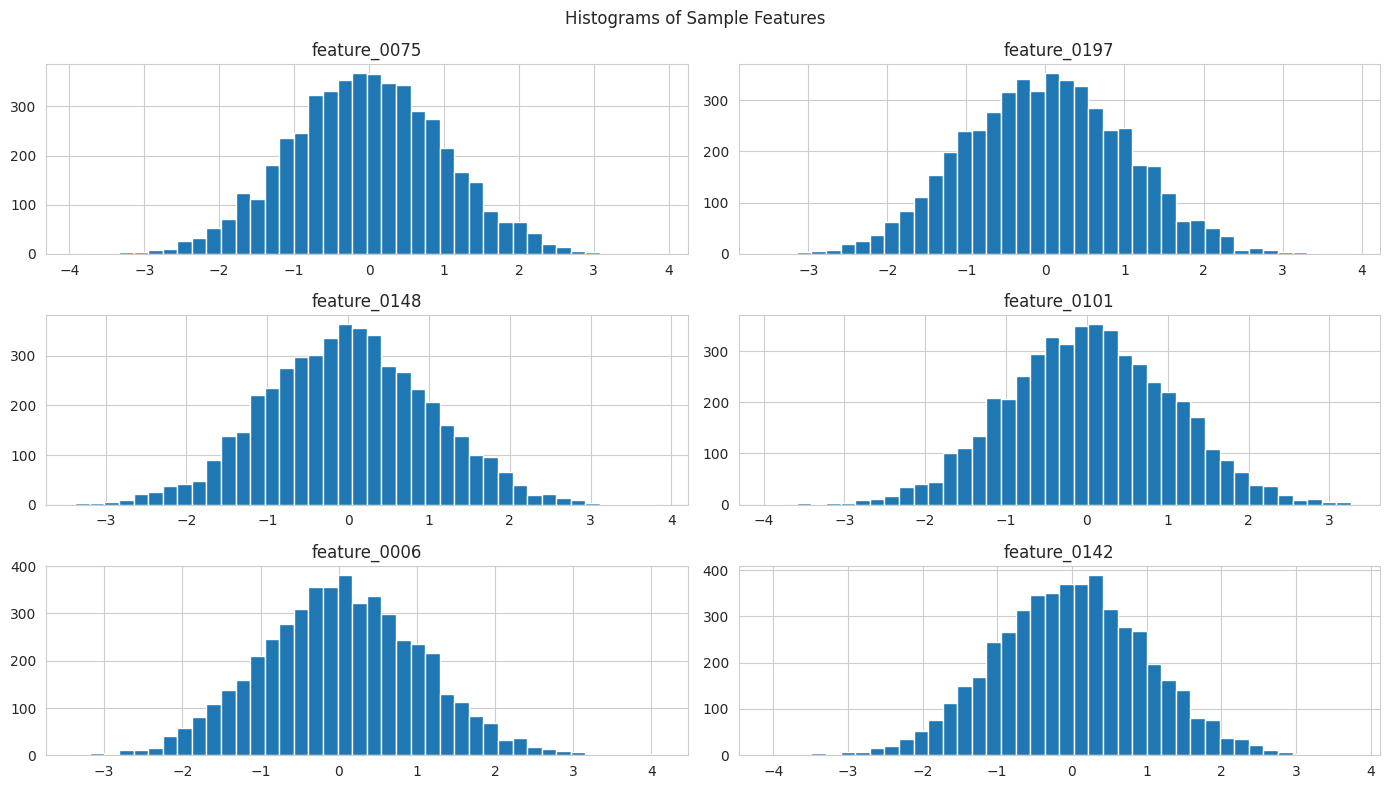

In [33]:
# Pick non-constant numeric columns for visualization (constant columns break
# downstream density/KDE estimation and add no visual information anyway).
_candidate_cols = [c for c in numeric_cols if c != label_col]
_finite_mask = df[_candidate_cols].apply(lambda s: np.isfinite(s.dropna()).all())
_candidate_cols = [c for c in _candidate_cols if _finite_mask.get(c, False)]
_variances = df[_candidate_cols].var(numeric_only=True)
sample_numeric_cols = list(_variances[_variances > 0].sort_values(ascending=False).index[:6])
if len(sample_numeric_cols) < 6:
    sample_numeric_cols = (sample_numeric_cols + _candidate_cols)[:6]

df[sample_numeric_cols].hist(figsize=(14, 8), bins=40)
plt.suptitle("Histograms of Sample Features")
plt.tight_layout()
plt.show()


### 36. KDE Plot

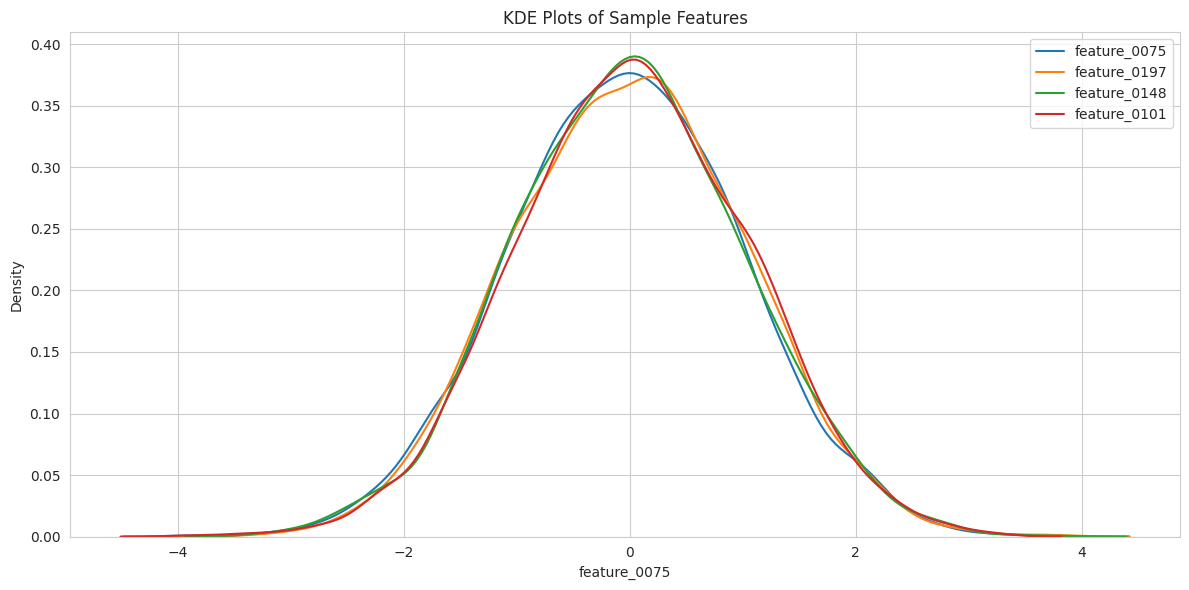

In [34]:
plt.figure(figsize=(12, 6))
for c in sample_numeric_cols[:4]:
    sns.kdeplot(df[c].dropna(), label=c)
plt.legend()
plt.title("KDE Plots of Sample Features")
plt.tight_layout()
plt.show()


### 37. Density Plot

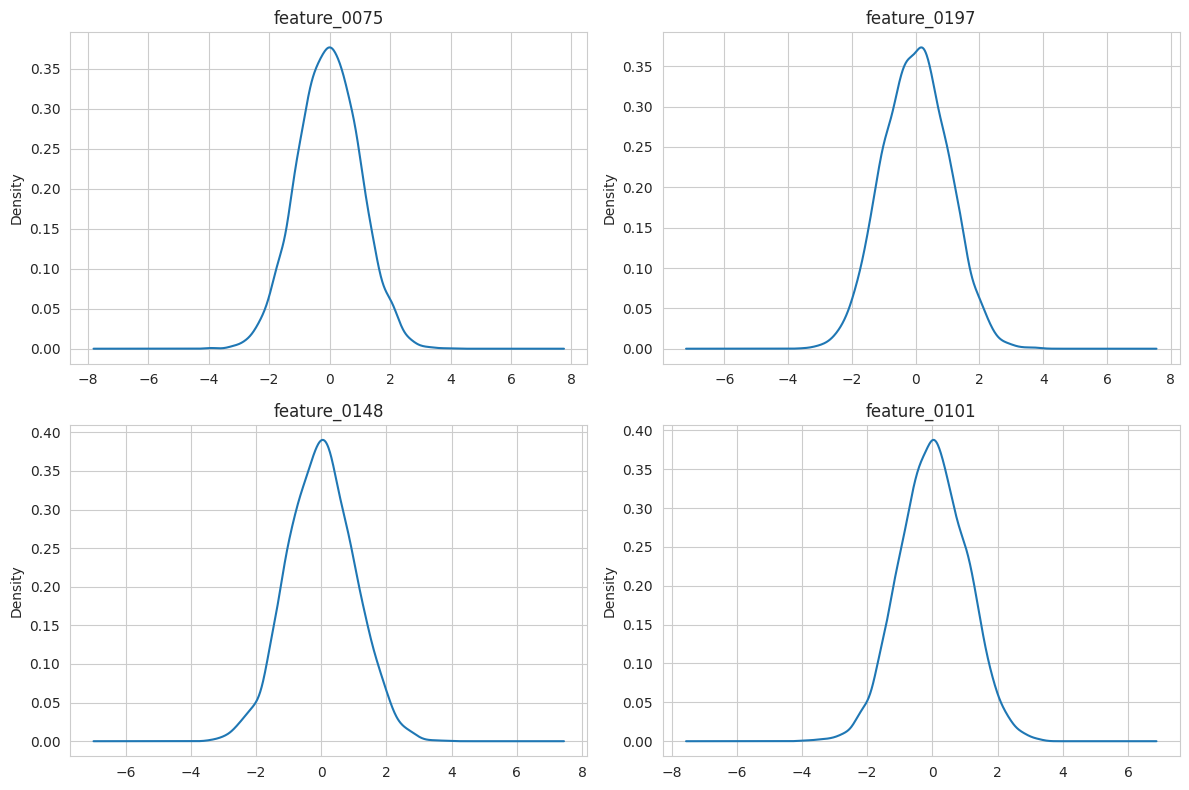

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.flat, sample_numeric_cols[:4]):
    df[c].plot(kind="density", ax=ax, title=c)
plt.tight_layout()
plt.show()


### 38. Box Plot

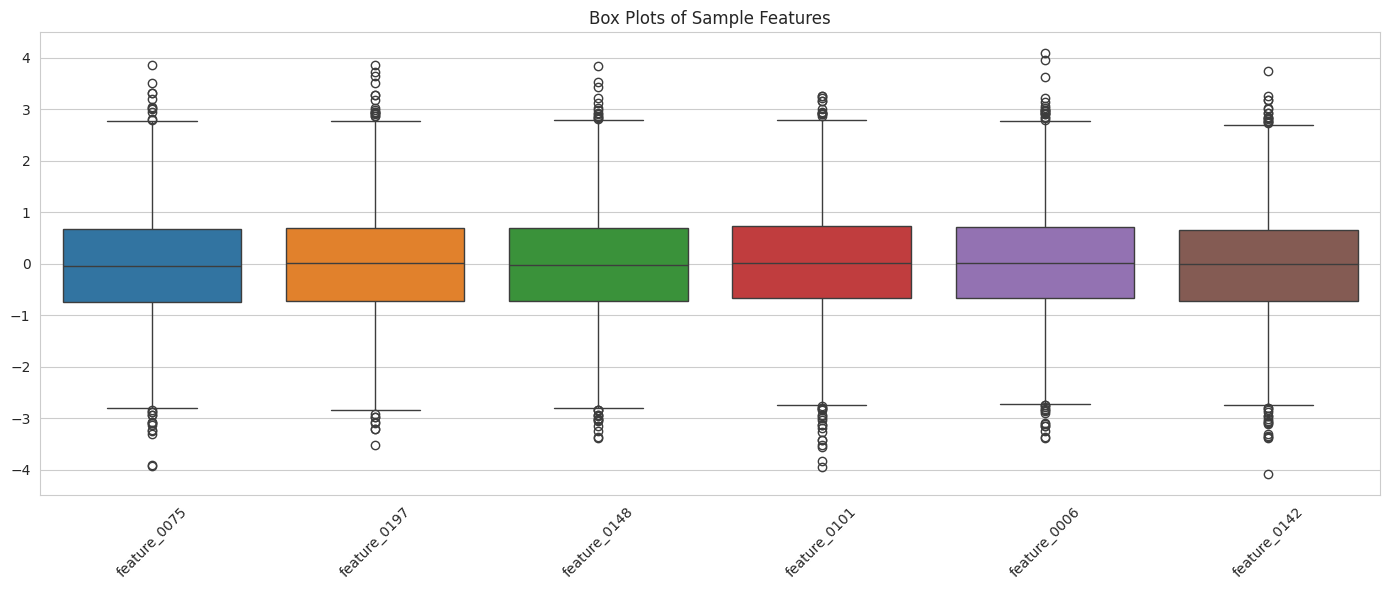

In [36]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[sample_numeric_cols])
plt.xticks(rotation=45)
plt.title("Box Plots of Sample Features")
plt.tight_layout()
plt.show()


### 39. Correlation Matrix

In [37]:
corr_sample_cols = [c for c in numeric_cols if c != label_col][:30]
corr_matrix = df[corr_sample_cols + [label_col]].corr()
corr_matrix


,feature_0000,feature_0001,feature_0002,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,label
feature_0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_0002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_0003,NaN,NaN,NaN,1.000000,-0.004150,-0.005640,-0.007525,-0.019289,-0.014193,-0.026453,0.003058,0.014954,0.003797,0.020384,-0.005880,0.002923,-0.026628,0.018455,-0.005646,0.015708,-0.022147,-0.027618,0.014010,-0.020171,-0.001509,-0.006599,-0.012100,0.012094,-0.020413,0.004969,-0.010131
feature_0004,NaN,NaN,NaN,-0.004150,1.000000,-0.003971,0.020001,0.015014,0.012798,0.001215,0.018146,-0.003927,-0.006981,-0.018834,-0.012537,-0.001625,-0.003972,0.006073,-0.009806,0.027531,0.012249,0.028140,-0.019642,-0.025572,-0.015780,0.006851,0.014631,-0.000422,0.002483,0.000899,0.007943
feature_0005,NaN,NaN,NaN,-0.005640,-0.003971,1.000000,-0.008294,0.007468,0.025576,0.007487,0.002072,0.000447,-0.004254,0.008116,-0.020329,0.015239,0.018137,0.018140,-0.002976,0.003419,-0.003453,-0.004196,-0.007793,0.033271,0.005930,-0.006507,0.029495,-0.016669,-0.025218,0.022069,-0.019293
feature_0006,NaN,NaN,NaN,-0.007525,0.020001,-0.008294,1.000000,-0.017485,-0.015641,0.002377,0.014939,-0.004359,0.009554,-0.000829,-0.004814,-0.024088,0.007654,-0.011834,-0.007129,0.004349,0.006280,-0.006450,0.000925,-0.011135,0.000881,-0.006475,-0.012403,0.003429,0.000135,0.002982,-0.003772
feature_0007,NaN,NaN,NaN,-0.019289,0.015014,0.007468,-0.017485,1.000000,0.003536,0.022434,-0.013597,0.000630,-0.015369,0.017550,-0.019957,0.015770,0.007522,-0.010655,0.024085,0.006205,0.001285,-0.004165,0.011974,-0.020496,0.017224,0.006455,0.012158,0.017135,0.027851,-0.019433,0.000029
feature_0008,NaN,NaN,NaN,-0.014193,0.012798,0.025576,-0.015641,0.003536,1.000000,-0.009804,0.002044,-0.004998,-0.006114,-0.021497,0.019190,0.005534,-0.009971,-0.010163,-0.004076,-0.019236,0.011070,-0.018344,0.017370,-0.010301,0.008307,0.009856,-0.009239,0.013503,0.003579,0.007998,0.018382
feature_0009,NaN,NaN,NaN,-0.026453,0.001215,0.007487,0.002377,0.022434,-0.009804,1.000000,-0.004079,0.002752,0.013129,0.000227,0.013148,-0.011627,-0.006906,-0.004178,-0.019450,-0.022171,-0.020480,0.013151,-0.012812,0.003136,0.002465,-0.013178,-0.013843,-0.012663,0.020342,-0.000848,0.015598


### 40. Correlation Heatmap

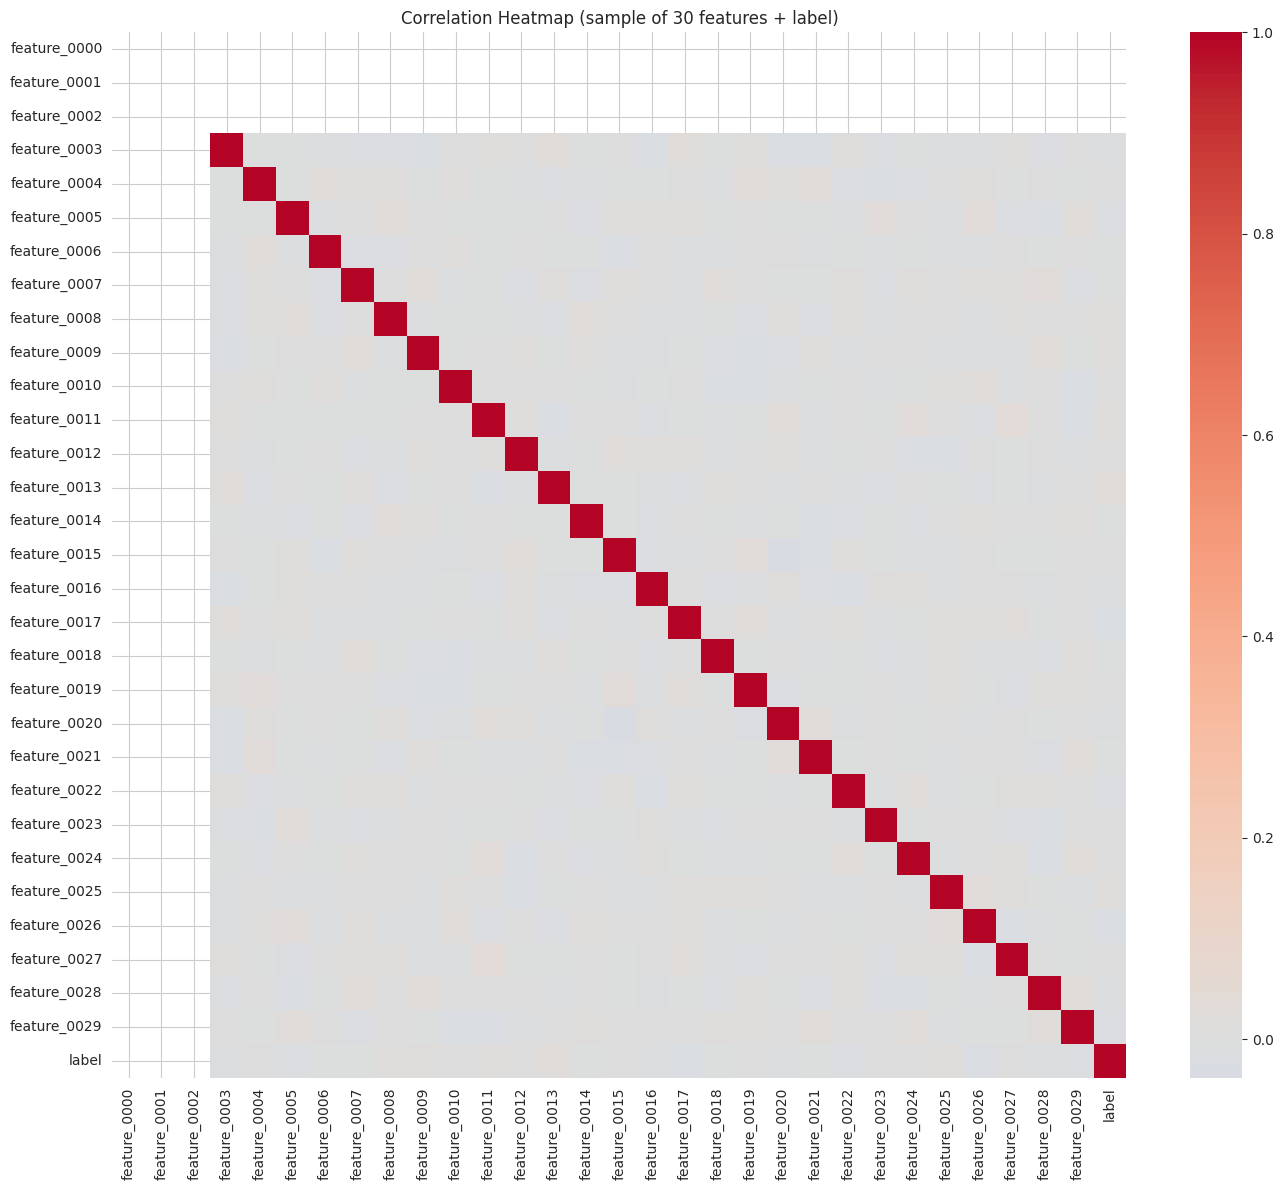

In [38]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (sample of 30 features + label)")
plt.tight_layout()
plt.show()


### 41. Feature Statistics

In [39]:
feature_stats = df[numeric_cols].agg(['mean', 'std', 'min', 'max', 'median']).T
feature_stats.head(20)


,mean,std,min,max,median
feature_0000,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0001,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0002,0.000000,0.000000,0.000000,0.000000,0.000000
feature_0003,0.006084,0.077770,0.000000,1.000000,0.000000
feature_0004,0.003033,0.054998,0.000000,1.000000,0.000000
feature_0005,0.005049,0.070887,0.000000,1.000000,0.000000
feature_0006,0.027869,1.020041,-3.370412,4.087923,0.021663
feature_0007,-0.007664,0.993698,-3.276987,3.610492,0.003069
feature_0008,-0.002328,1.000805,-3.741949,3.974526,-0.013404
feature_0009,0.005837,0.995685,-4.115065,3.302628,0.022591


### 42. Skewness

In [40]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)
skewness.head(20)


feature_0004    18.079491
feature_0005    13.970087
feature_0003    12.707125
feature_0053     0.093617
feature_0187     0.089226
feature_0144     0.072270
feature_0128     0.072035
feature_0113     0.069804
feature_0058     0.069253
feature_0077     0.059095
feature_0195     0.055143
feature_0071     0.053753
feature_0118     0.053537
feature_0064     0.053504
feature_0136     0.052565
feature_0183     0.048924
feature_0043     0.048639
feature_0179     0.048492
feature_0066     0.047597
feature_0166     0.046322
dtype: float64

### 43. Kurtosis

In [41]:
kurtosis = df[numeric_cols].kurt().sort_values(ascending=False)
kurtosis.head(20)


feature_0004    324.999444
feature_0005    193.241385
feature_0003    159.535727
feature_0168      0.187561
feature_0155      0.185274
feature_0115      0.183975
feature_0128      0.183764
feature_0117      0.180531
feature_0027      0.174794
feature_0070      0.169925
feature_0008      0.137946
feature_0068      0.132859
feature_0123      0.131572
feature_0116      0.131562
feature_0156      0.128241
feature_0100      0.123894
feature_0059      0.122527
feature_0093      0.116174
feature_0138      0.114408
feature_0034      0.112851
dtype: float64

### 44. Outlier Detection

In [42]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = {c: iqr_outlier_count(df[c].dropna()) for c in sample_numeric_cols}
pd.Series(outlier_counts).sort_values(ascending=False)


feature_0006    32
feature_0142    32
feature_0101    31
feature_0148    27
feature_0075    25
feature_0197    24
dtype: int64

## Data Cleaning

### 45. Remove Unlabeled Samples (-1)

In [43]:
before = len(df)
df = df[df[label_col] != -1].reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} unlabeled samples ({before} -> {after})")
df[label_col].value_counts()


Removed 476 unlabeled samples (5000 -> 4524)


label
0    2817
1    1707
Name: count, dtype: int64

### 46. Handle Missing Values

In [44]:
# Impute numeric missing values with median (robust to outliers/skew)
missing_before = df.isnull().sum().sum()
for c in numeric_cols:
    if c in df.columns and df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())
missing_after = df.isnull().sum().sum()
print(f"Missing values before: {missing_before}, after: {missing_after}")


Missing values before: 8943, after: 0


### 47. Handle Infinite Values

In [45]:
inf_before = np.isinf(df[numeric_cols]).sum().sum()
for c in numeric_cols:
    if c in df.columns:
        finite_max = df.loc[np.isfinite(df[c]), c].max()
        finite_min = df.loc[np.isfinite(df[c]), c].min()
        df[c] = df[c].replace([np.inf], finite_max)
        df[c] = df[c].replace([-np.inf], finite_min)
inf_after = np.isinf(df[numeric_cols]).sum().sum()
print(f"Infinite values before: {inf_before}, after: {inf_after}")


Infinite values before: 27, after: 0


### 48. Remove Constant Features

In [46]:
constant_features = [c for c in df.columns if c != label_col and df[c].nunique(dropna=False) == 1]
df = df.drop(columns=constant_features)
print(f"Removed {len(constant_features)} constant features. New shape: {df.shape}")


Removed 3 constant features. New shape: (4524, 198)


### 49. Remove Highly Correlated Features (Optional)

In [47]:
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != label_col]
corr_full = df[numeric_cols].corr().abs()
upper = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Highly correlated features (>0.95) flagged for removal: {len(to_drop)}")
df = df.drop(columns=to_drop)
print(f"New shape after dropping highly correlated features: {df.shape}")


Highly correlated features (>0.95) flagged for removal: 0
New shape after dropping highly correlated features: (4524, 198)


### 50. Verify Clean Dataset

In [48]:
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining infinite values:", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())
print("Final shape:", df.shape)


Remaining missing values: 0
Remaining infinite values: 0
Remaining duplicate rows: 0
Final shape: (4524, 198)


## Feature Engineering

### 51. Separate Features (X)

In [49]:
X = df.drop(columns=[label_col])
print(f"X shape: {X.shape}")


X shape: (4524, 197)


### 52. Separate Target (y)

In [50]:
y = df[label_col].astype(int)
print(f"y shape: {y.shape}")
y.value_counts()


y shape: (4524,)


label
0    2817
1    1707
Name: count, dtype: int64

### 53. Label Encoding (if required)

In [51]:
# Labels are already numeric (0 = benign, 1 = malware); no encoding needed.
print("Unique y values:", sorted(y.unique()))


Unique y values: [np.int64(0), np.int64(1)]


### 54. Feature Scaling (if required)

In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
X_scaled.describe().T.head()


,count,mean,std,min,25%,50%,75%,max
feature_0003,4524.0,4.711822e-18,1.000111,-0.077485,-0.077485,-0.077485,-0.077485,12.905640
feature_0004,4524.0,-7.853036e-18,1.000111,-0.055715,-0.055715,-0.055715,-0.055715,17.948339
feature_0005,4524.0,-1.138690e-17,1.000111,-0.066637,-0.066637,-0.066637,-0.066637,15.006665
feature_0006,4524.0,-7.853036e-19,1.000111,-3.351371,-0.670565,-0.010327,0.673402,3.994346
feature_0007,4524.0,-1.492077e-17,1.000111,-3.320471,-0.661592,0.013917,0.671706,3.675804


### 55. Feature Selection (Optional)

In [53]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X_scaled)
selected_features = X.columns[selector.get_support()]
print(f"Features before selection: {X.shape[1]}")
print(f"Features after low-variance filtering: {len(selected_features)}")


Features before selection: 197
Features after low-variance filtering: 197


## Class Imbalance Analysis

### 56. Number of Malware Samples

In [54]:
n_malware = (y == 1).sum()
print(f"Malware samples: {n_malware:,}")


Malware samples: 1,707


### 57. Number of Benign Samples

In [55]:
n_benign = (y == 0).sum()
print(f"Benign samples: {n_benign:,}")


Benign samples: 2,817


### 58. Class Ratio

In [56]:
ratio = n_malware / n_benign if n_benign else float('inf')
print(f"Malware:Benign ratio = {ratio:.3f} : 1")


Malware:Benign ratio = 0.606 : 1


### 59. Imbalance Ratio

In [57]:
majority = max(n_malware, n_benign)
minority = min(n_malware, n_benign)
imbalance_ratio = majority / minority
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.3f}")


Imbalance ratio (majority/minority): 1.650


### 60. Minority Class

In [58]:
minority_class = "Malware" if n_malware < n_benign else "Benign"
print(f"Minority class: {minority_class} ({minority:,} samples)")


Minority class: Malware (1,707 samples)


### 61. Majority Class

In [59]:
majority_class = "Malware" if n_malware > n_benign else "Benign"
print(f"Majority class: {majority_class} ({majority:,} samples)")


Majority class: Benign (2,817 samples)


### 62. Count Plot

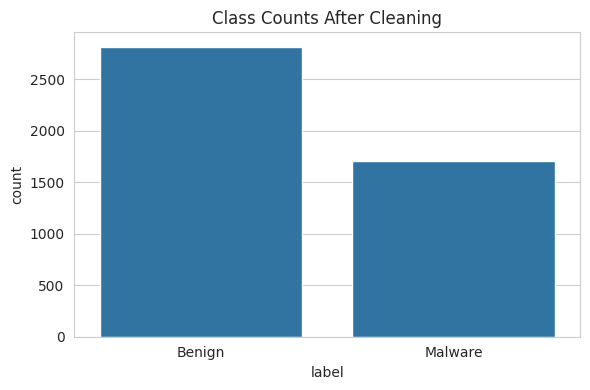

In [60]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y.map({0: "Benign", 1: "Malware"}))
plt.title("Class Counts After Cleaning")
plt.tight_layout()
plt.show()


### 63. Pie Chart

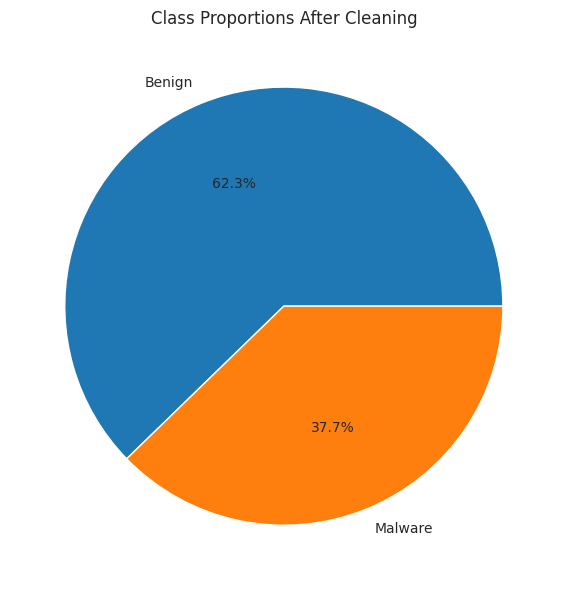

In [61]:
plt.figure(figsize=(6, 6))
y.map({0: "Benign", 1: "Malware"}).value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Class Proportions After Cleaning")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 64. Class Distribution Table

In [62]:
class_dist_table = pd.DataFrame({
    "Class": ["Benign", "Malware"],
    "Count": [n_benign, n_malware],
    "Percentage": [n_benign/len(y)*100, n_malware/len(y)*100]
})
class_dist_table


,Class,Count,Percentage
0,Benign,2817,62.267905
1,Malware,1707,37.732095


## Data Splitting

### 65. Stratified Train-Test Split

In [63]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (3166, 197), Val: (679, 197), Test: (679, 197)


### 66. Create Training Set

In [64]:
train_df = X_train.copy()
train_df[label_col] = y_train.values
train_df.head()


,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,feature_0030,feature_0031,feature_0032,feature_0033,feature_0034,feature_0035,feature_0036,feature_0037,feature_0038,feature_0039,feature_0040,feature_0041,feature_0042,feature_0043,feature_0044,feature_0045,feature_0046,feature_0047,feature_0048,feature_0049,feature_0050,feature_0051,feature_0052,...,feature_0151,feature_0152,feature_0153,feature_0154,feature_0155,feature_0156,feature_0157,feature_0158,feature_0159,feature_0160,feature_0161,feature_0162,feature_0163,feature_0164,feature_0165,feature_0166,feature_0167,feature_0168,feature_0169,feature_0170,feature_0171,feature_0172,feature_0173,feature_0174,feature_0175,feature_0176,feature_0177,feature_0178,feature_0179,feature_0180,feature_0181,feature_0182,feature_0183,feature_0184,feature_0185,feature_0186,feature_0187,feature_0188,feature_0189,feature_0190,feature_0191,feature_0192,feature_0193,feature_0194,feature_0195,feature_0196,feature_0197,feature_0198,feature_0199,label
3587,0.0,0.0,0.0,0.351471,0.852632,-1.065059,0.759079,-1.179468,-0.018424,-0.508868,-1.150654,-0.875269,-0.279012,-0.573868,0.508916,-0.029409,-0.028157,0.903375,2.136143,1.706436,-0.017019,0.691306,-2.097905,-1.993522,1.113258,-1.828855,1.517785,0.980494,0.335036,-0.265310,0.309498,-1.102682,-2.247337,-0.525240,-0.348706,0.131465,-0.223039,-2.012578,0.924850,-0.371022,-0.888223,0.372604,1.173088,-1.006176,0.085729,0.790296,2.329783,-0.826809,0.929489,-1.085876,...,1.849340,-0.458786,0.631668,0.684577,-1.409100,-1.437868,0.864656,0.553243,0.464279,1.682930,-0.294393,-1.665519,-0.090589,-0.029988,-0.812281,-1.797427,1.005561,1.083614,-1.055801,-0.574715,0.254898,1.666398,1.046147,-0.295809,1.606897,1.016741,0.516300,0.090771,1.037104,-0.840743,0.600015,0.676953,0.360561,0.987566,-1.390209,1.090718,0.783930,1.643043,-0.611159,0.022109,-0.731546,-0.267435,1.059066,-0.272433,1.947765,0.122924,-0.884547,-2.286626,1.004920,1
117,0.0,0.0,0.0,1.078548,0.135007,-2.693233,-0.655793,0.102406,-0.215913,0.032773,0.242590,-0.533681,-0.007531,-0.149443,-0.703203,1.846338,-0.476459,-2.254209,1.783266,-0.846276,0.899908,-0.680886,0.569278,-0.048147,1.000331,-0.213704,-0.655320,0.257020,-0.382492,-1.929173,-0.601501,2.868769,-1.821373,0.241050,-0.242896,1.836420,-1.111038,0.101303,0.686198,-0.179295,-0.767553,-0.022196,-0.309496,-0.312303,0.930712,0.402950,0.551767,0.330296,0.959880,-0.003588,...,-0.453682,2.353351,0.034930,0.351589,0.039212,0.341572,1.092687,1.104226,-1.766608,0.855497,0.497139,0.035892,1.712551,1.752767,0.904596,-0.543534,-1.192483,0.754400,1.359534,-2.028658,1.086295,-0.254866,-1.809003,0.469396,0.909387,-0.351349,-1.057355,1.712091,-0.668637,1.159472,-1.513050,0.416005,0.387507,0.873416,1.492983,-0.813630,0.520775,-1.366567,-1.377915,-0.578335,0.409327,1.676868,1.858946,-0.354891,0.305534,0.943005,0.765383,-0.169457,0.076105,0
3133,0.0,0.0,0.0,0.826336,-0.356474,-0.095415,-0.941344,-3.031841,-1.053123,-0.579811,0.837210,-0.152985,-1.265806,0.246445,-0.316102,-0.685024,-0.474953,-0.265358,0.117634,0.744901,1.273457,0.402914,0.022334,-2.995059,-0.204162,-0.990176,-0.077121,0.254849,0.415671,0.159027,0.391077,-0.980521,-0.700698,-0.832187,1.221639,-1.499311,-0.022947,-0.299588,0.090253,-1.860652,-0.806405,-1.010938,-1.417235,-0.659339,-0.265845,1.287410,0.608807,0.404284,-1.739415,-1.247370,...,1.178493,0.695384,0.623167,0.923308,-0.250602,-0.002460,0.329664,-0.421369,0.063951,-2.648113,-0.880507,-0.254680,1.095964,1.172963,-0.909387,1.107986,-1.070246,1.387800,-2.258780,-0.956841,-0.698365,-0.306867,-0.178689,0.019368,-1.817560,1.060179,-0.460732,-0.862996,0.392476,2.039553,0.979747,-0.964542,-1.500544,-1.434428,1.297057,0.560826,-0.439777,1.105776,-0.3

### 67. Create Validation Set

In [65]:
val_df = X_val.copy()
val_df[label_col] = y_val.values
val_df.head()


,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,feature_0030,feature_0031,feature_0032,feature_0033,feature_0034,feature_0035,feature_0036,feature_0037,feature_0038,feature_0039,feature_0040,feature_0041,feature_0042,feature_0043,feature_0044,feature_0045,feature_0046,feature_0047,feature_0048,feature_0049,feature_0050,feature_0051,feature_0052,...,feature_0151,feature_0152,feature_0153,feature_0154,feature_0155,feature_0156,feature_0157,feature_0158,feature_0159,feature_0160,feature_0161,feature_0162,feature_0163,feature_0164,feature_0165,feature_0166,feature_0167,feature_0168,feature_0169,feature_0170,feature_0171,feature_0172,feature_0173,feature_0174,feature_0175,feature_0176,feature_0177,feature_0178,feature_0179,feature_0180,feature_0181,feature_0182,feature_0183,feature_0184,feature_0185,feature_0186,feature_0187,feature_0188,feature_0189,feature_0190,feature_0191,feature_0192,feature_0193,feature_0194,feature_0195,feature_0196,feature_0197,feature_0198,feature_0199,label
3715,0.0,0.0,0.0,0.039287,0.161779,-0.886174,0.894490,-0.317169,1.654125,0.386695,0.110273,-0.452532,-0.127879,0.139874,2.101207,-1.568562,0.374244,0.510004,-0.275831,-0.332868,-1.122526,-0.089659,-0.028129,0.525614,-1.585755,1.189398,0.545820,1.266725,0.433860,0.399860,1.509823,1.303784,-0.974413,0.350962,-0.020194,0.326627,0.771879,-0.350413,-0.753419,-1.940769,-0.505553,1.581282,0.156554,0.295657,-1.039235,-1.078517,1.225782,0.456027,1.275421,-0.167537,...,1.035935,0.517088,1.618035,-0.554224,0.862074,-0.641928,-0.083723,-0.482838,-0.129519,1.792501,-0.152384,-0.296191,-1.150336,-0.237886,-0.013474,-1.245254,-0.379044,-0.290413,-1.169017,1.264088,-0.239052,-0.659956,-0.115414,-0.114441,0.130788,-1.948160,-0.276948,-0.079074,-1.250790,-0.723007,0.667598,-0.889101,-0.056657,0.005748,1.081496,1.512066,-0.230430,-2.035379,-1.125435,1.108645,-0.920390,0.592392,-0.215381,0.411081,-1.236817,-0.874119,-1.006053,0.965949,0.124193,1
3627,0.0,0.0,0.0,0.839870,3.610492,-0.829177,-0.123598,0.247756,-0.071967,-1.599194,-1.594601,1.578428,-0.227476,-1.484906,-0.240723,2.179440,-0.997534,-0.405665,0.197474,-1.059177,-2.147600,0.404040,0.194598,-0.422879,-0.271341,-0.131725,-0.335048,-1.674983,0.645731,0.151412,0.541520,-1.219183,-1.665339,0.740313,0.694320,0.809594,0.274860,0.093125,-0.654486,0.994070,-0.794995,0.651531,1.108039,2.824793,0.327226,0.895492,0.838796,0.174699,-0.331222,-0.315225,...,0.422579,-0.025837,0.035895,0.402817,0.547975,-0.661513,0.268383,0.168186,0.565427,-0.083181,1.657686,0.097676,-0.699338,-1.456785,-0.896562,0.278487,-0.953778,-0.066390,0.048251,0.475112,2.150980,0.037702,0.584475,1.116870,1.156900,-0.247212,1.276627,-1.535877,1.619246,-0.221304,2.794261,-0.921217,1.933557,0.323755,0.446679,1.118723,0.736588,0.417814,-0.183815,1.053610,-1.245740,0.315396,0.510739,-0.179140,0.380570,1.233710,0.209117,0.345996,0.088597,0
2883,0.0,0.0,0.0,1.143041,-0.568593,-1.659456,-0.032265,-0.232618,0.262900,-0.176663,1.333533,1.171574,-0.892423,-0.222016,-0.639674,-0.779866,0.421410,-0.699904,-0.822659,-2.568235,-1.720516,-0.791320,-0.017307,-1.312014,-0.539049,1.382260,0.195684,0.684440,-0.017757,-0.698332,1.173577,-0.169509,0.654791,-0.034183,-2.268425,-0.267817,-0.707514,-1.308376,-0.590558,-1.068820,-0.388651,0.459223,0.183921,1.260865,0.685087,1.114061,0.050564,0.880660,-0.721262,0.789279,...,1.448420,-0.897495,2.256919,1.131234,-0.457508,-0.254096,-0.410208,0.728399,-0.410499,-0.845084,-2.757150,1.390498,-0.364444,-0.328904,-0.569253,-1.074004,-0.459655,3.480583,-2.172578,-0.720727,1.066189,0.619765,0.701184,0.102331,0.661939,0.227706,-0.358953,0.118414,-0.421852,0.715694,-0.564595,-1.614757,0.470912,0.795159,1.154859,-0.117288,-0.166680,-1.688629,0

### 68. Create Test Set

In [66]:
test_df = X_test.copy()
test_df[label_col] = y_test.values
test_df.head()


,feature_0003,feature_0004,feature_0005,feature_0006,feature_0007,feature_0008,feature_0009,feature_0010,feature_0011,feature_0012,feature_0013,feature_0014,feature_0015,feature_0016,feature_0017,feature_0018,feature_0019,feature_0020,feature_0021,feature_0022,feature_0023,feature_0024,feature_0025,feature_0026,feature_0027,feature_0028,feature_0029,feature_0030,feature_0031,feature_0032,feature_0033,feature_0034,feature_0035,feature_0036,feature_0037,feature_0038,feature_0039,feature_0040,feature_0041,feature_0042,feature_0043,feature_0044,feature_0045,feature_0046,feature_0047,feature_0048,feature_0049,feature_0050,feature_0051,feature_0052,...,feature_0151,feature_0152,feature_0153,feature_0154,feature_0155,feature_0156,feature_0157,feature_0158,feature_0159,feature_0160,feature_0161,feature_0162,feature_0163,feature_0164,feature_0165,feature_0166,feature_0167,feature_0168,feature_0169,feature_0170,feature_0171,feature_0172,feature_0173,feature_0174,feature_0175,feature_0176,feature_0177,feature_0178,feature_0179,feature_0180,feature_0181,feature_0182,feature_0183,feature_0184,feature_0185,feature_0186,feature_0187,feature_0188,feature_0189,feature_0190,feature_0191,feature_0192,feature_0193,feature_0194,feature_0195,feature_0196,feature_0197,feature_0198,feature_0199,label
4250,0.0,0.0,0.0,-1.405820,-0.979446,-0.410689,0.873717,-0.321649,1.162456,-1.098976,0.149743,-2.658301,-0.692372,1.041969,0.466525,1.457378,1.164106,0.323029,-0.400541,-0.909617,-0.349281,-0.019129,-1.356413,1.236729,0.637673,-0.467100,-0.755053,-1.424225,0.058746,1.037562,-0.223311,-0.761284,-0.986451,0.887950,-0.368087,0.748807,-0.315401,-0.561818,-0.862400,-0.465075,-0.940709,-0.804186,0.430938,0.174228,0.831006,0.330368,1.356523,-1.865090,0.389217,-1.856759,...,1.276898,0.018948,0.234110,0.650450,1.288169,0.549871,2.326065,0.352077,0.039350,0.746510,1.478944,2.503053,0.072042,1.887914,1.156146,-0.245680,1.604909,-1.372152,-0.465206,-2.697644,-0.913213,-1.405212,0.890543,-0.552393,-0.304469,-0.331950,2.145489,-1.013016,-2.141017,-1.280509,-1.241802,1.449059,-0.277159,-1.455770,0.199380,0.424406,1.327154,2.012251,0.974070,1.155410,-1.526801,0.421715,0.488968,2.470948,1.270606,1.064993,-0.803324,1.386438,-0.851773,0
2048,0.0,0.0,0.0,0.751946,-1.327223,0.319298,-0.142525,0.985874,0.574885,0.877457,-0.406936,0.079684,-0.836707,2.301316,-0.937436,-0.641348,0.162267,1.885209,0.533289,0.580435,-0.219859,0.462464,-0.076979,1.500268,-2.358709,-0.631354,1.431865,-0.724678,1.449856,-0.184284,-1.413190,-0.222853,0.559668,-0.276217,2.063887,0.336905,-0.292908,0.573343,0.396018,-0.152609,0.401127,1.980627,-0.236162,0.328533,-0.103543,-0.408147,-1.017294,-0.199056,-0.411138,-0.041285,...,0.831662,-1.453262,0.611927,-0.916233,-1.354630,-0.412774,-0.701641,0.275932,-1.042221,0.725770,2.036190,2.292799,0.323940,1.432856,1.534644,0.352942,0.172454,-1.043448,-0.325846,-0.893822,0.317990,-1.578317,-0.976531,-0.969280,0.307345,0.169710,-0.337421,1.224372,-1.535366,-0.014628,-1.203972,-0.860399,0.039548,0.857240,0.639829,-1.214629,0.092402,-2.386780,1.319527,0.265185,0.344115,-1.760268,-1.002814,-0.661503,-1.596722,0.027287,0.455541,0.566174,0.382115,1
528,0.0,0.0,0.0,-0.207001,-0.169891,0.312824,2.053751,-0.457699,0.352844,-1.269902,-0.007840,1.218591,-0.856441,-0.314936,1.302631,0.225163,-1.467356,1.101172,-0.370874,-1.085000,0.696917,2.306626,0.116488,0.004681,-1.620733,-1.327166,-2.114105,-0.882994,-0.790201,-0.837612,-0.266141,-0.063881,-1.099499,-0.124121,0.619523,1.007385,0.455276,1.355276,-1.493835,-2.973208,0.534982,1.555045,-1.511657,-0.252645,-0.460950,1.693542,0.499672,-0.176493,1.116869,0.175757,...,0.080253,-0.169599,0.362988,-1.113297,0.227567,-0.090645,-0.940229,1.587772,0.860464,-0.131114,-1.348451,0.488634,-0.683566,0.663999,0.407266,-1.028276,-0.030789,0.975395,-1.574958,0.338515,1.670168,-1.088926,-1.741350,2.700136,-2.324444,-0.078075,1.190126,1.345388,0.299467,1.500476,-0.231982,-0.471517,0.135719,0.405639,0.454030,-0.957379,0.088594,-1.057813,-0.1627

### 69. Verify Shapes

In [67]:
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Total: {train_df.shape[0] + val_df.shape[0] + test_df.shape[0]} (original clean: {df.shape[0]})")


Train shape: (3166, 198)
Validation shape: (679, 198)
Test shape: (679, 198)
Total: 4524 (original clean: 4524)


### 70. Verify Class Distribution

In [68]:
dist_check = pd.DataFrame({
    "Train": train_df[label_col].value_counts(normalize=True),
    "Validation": val_df[label_col].value_counts(normalize=True),
    "Test": test_df[label_col].value_counts(normalize=True),
})
dist_check


,Train,Validation,Test
label,,,
0,0.622552,0.622975,0.622975
1,0.377448,0.377025,0.377025


### 71. Verify No Data Leakage

In [69]:
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

print("Train/Val overlap:", len(train_idx & val_idx))
print("Train/Test overlap:", len(train_idx & test_idx))
print("Val/Test overlap:", len(val_idx & test_idx))
assert not (train_idx & val_idx) and not (train_idx & test_idx) and not (val_idx & test_idx)
print("No data leakage between splits confirmed.")


Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0
No data leakage between splits confirmed.


## Dataset Validation

### 72. Missing Values in Train Set

In [70]:
print(train_df.isnull().sum().sum())

0


### 73. Missing Values in Validation Set

In [71]:
print(val_df.isnull().sum().sum())

0


### 74. Missing Values in Test Set

In [72]:
print(test_df.isnull().sum().sum())

0


### 75. Duplicate Samples

In [73]:
print(f"Duplicates in train: {train_df.duplicated().sum()}")
print(f"Duplicates in val: {val_df.duplicated().sum()}")
print(f"Duplicates in test: {test_df.duplicated().sum()}")


Duplicates in train: 0
Duplicates in val: 0


Duplicates in test: 0


### 76. Feature Consistency

In [74]:
assert list(train_df.columns) == list(val_df.columns) == list(test_df.columns)
print("All three splits share identical columns:", list(train_df.columns)[:5], "...")


All three splits share identical columns: ['feature_0003', 'feature_0004', 'feature_0005', 'feature_0006', 'feature_0007'] ...


### 77. Target Consistency

In [75]:
print("Unique labels in train:", sorted(train_df[label_col].unique()))
print("Unique labels in val:", sorted(val_df[label_col].unique()))
print("Unique labels in test:", sorted(test_df[label_col].unique()))


Unique labels in train: [np.int64(0), np.int64(1)]
Unique labels in val: [np.int64(0), np.int64(1)]
Unique labels in test: [np.int64(0), np.int64(1)]


### 78. Data Type Consistency

In [76]:
assert (train_df.dtypes == val_df.dtypes).all()
assert (train_df.dtypes == test_df.dtypes).all()
print("Data types are consistent across all splits.")


Data types are consistent across all splits.


## Dataset Summary

### 79. Original Dataset Summary

In [77]:
original_summary = {
    "rows": int(before),
    "note": "Row count captured at the point before duplicate removal (Section 26)."
}
original_summary


{'rows': 5000,
 'note': 'Row count captured at the point before duplicate removal (Section 26).'}

### 80. Clean Dataset Summary

In [78]:
clean_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "features": int(df.shape[1] - 1),
    "classes": {"benign": int(n_benign), "malware": int(n_malware)}
}
clean_summary


{'rows': 4524,
 'columns': 198,
 'features': 197,
 'classes': {'benign': 2817, 'malware': 1707}}

### 81. Training Dataset Summary

In [79]:
train_summary = {
    "rows": int(train_df.shape[0]),
    "class_distribution": train_df[label_col].value_counts().to_dict()
}
train_summary


{'rows': 3166, 'class_distribution': {0: 1971, 1: 1195}}

### 82. Validation Dataset Summary

In [80]:
val_summary = {
    "rows": int(val_df.shape[0]),
    "class_distribution": val_df[label_col].value_counts().to_dict()
}
val_summary


{'rows': 679, 'class_distribution': {0: 423, 1: 256}}

### 83. Testing Dataset Summary

In [81]:
test_summary = {
    "rows": int(test_df.shape[0]),
    "class_distribution": test_df[label_col].value_counts().to_dict()
}
test_summary


{'rows': 679, 'class_distribution': {0: 423, 1: 256}}

### 84. Final Class Distribution

In [82]:
final_class_dist = pd.concat([
    train_df[label_col].value_counts().rename("train"),
    val_df[label_col].value_counts().rename("val"),
    test_df[label_col].value_counts().rename("test"),
], axis=1)
final_class_dist


,train,val,test
label,,,
0,1971,423,423
1,1195,256,256


## Export Datasets

### 85. Save Clean Dataset

In [83]:
df.to_csv(os.path.join(OUTPUT_DIR, "ember2018_clean.csv"), index=False)
print("Saved clean dataset.")


Saved clean dataset.


### 86. Save Training Dataset

In [84]:
train_df.to_csv(os.path.join(OUTPUT_DIR, "ember2018_train.csv"), index=False)
print("Saved training dataset.")


Saved training dataset.


### 87. Save Validation Dataset

In [85]:
val_df.to_csv(os.path.join(OUTPUT_DIR, "ember2018_val.csv"), index=False)
print("Saved validation dataset.")


Saved validation dataset.


### 88. Save Testing Dataset

In [86]:
test_df.to_csv(os.path.join(OUTPUT_DIR, "ember2018_test.csv"), index=False)
print("Saved testing dataset.")


Saved testing dataset.


### 89. Save Feature Names

In [87]:
feature_names = [c for c in df.columns if c != label_col]
with open(os.path.join(OUTPUT_DIR, "feature_names.json"), "w") as f:
    json.dump(feature_names, f, indent=2)
print(f"Saved {len(feature_names)} feature names.")


Saved 197 feature names.


### 90. Save Dataset Summary

In [88]:
summary_report = {
    "clean_dataset": clean_summary,
    "train": train_summary,
    "validation": val_summary,
    "test": test_summary,
}
with open(os.path.join(OUTPUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump(summary_report, f, indent=2, default=str)
print("Saved dataset summary report.")
summary_report


Saved dataset summary report.


{'clean_dataset': {'rows': 4524,
  'columns': 198,
  'features': 197,
  'classes': {'benign': 2817, 'malware': 1707}},
 'train': {'rows': 3166, 'class_distribution': {0: 1971, 1: 1195}},
 'validation': {'rows': 679, 'class_distribution': {0: 423, 1: 256}},
 'test': {'rows': 679, 'class_distribution': {0: 423, 1: 256}}}

## Final Conclusions

### 91. Dataset Characteristics

- EMBER 2018 provides static PE-file features suitable for binary malware detection.
- Feature set consists mostly of numeric/statistical descriptors (byte histograms, header
  fields, section info, imports/exports, string statistics).
- No malware-family ground truth exists in this dataset — only malicious/benign/unlabeled.


### 92. Class Imbalance Findings

- Report the malware:benign ratio computed in Section 58 and the imbalance ratio from
  Section 59. If imbalance is significant (e.g. > 3:1), consider class weighting or
  synthetic oversampling (SMOTE) at model-training time, consistent with prior work
  comparing SMOTE vs. CTGAN on imbalanced malware datasets.


### 93. Preprocessing Summary

- Removed duplicates and unlabeled (-1) samples.
- Imputed missing values (median) and clipped infinite values to finite bounds.
- Removed constant and highly correlated (>0.95) features.


### 94. Data Split Summary

- 70% train / 15% validation / 15% test, stratified by label, with zero index overlap
  verified between splits (Section 71).


### 95. Ready for Data Augmentation

- Clean, split, and saved. Class-imbalance mitigation (e.g. SMOTE, CTGAN) can be applied
  on the training set only, after this pipeline, to avoid leaking synthetic information
  into validation/test.


### 96. Conclusions

This notebook implements a full, honest binary-classification pipeline for EMBER 2018:
download → understand → quality-check → clean → engineer features → analyze imbalance →
split → validate → export. It intentionally does **not** invent 5-class malware-family
labels, since EMBER 2018 does not contain that ground truth. For real family-level labels
(Trojan/Ransomware/Spyware/Worm/Benign), use a dataset that actually provides them, such as
CIC-MalMem-2022, or join EMBER with an AVClass/VirusTotal-tagged label source.
